In [1]:
import icdv as icdv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%matplotlib widget

In [3]:
# 2) Cargar todos los CSV (rápido)
df_all = icdv.processing.cargar_csv_arbin("/home/mariajose/proc-icdv/notebooks/tmp/ARBIN_jd_grcom_sw3_c_1_sinresorte_doslanavidrio")
df_all.head()


,Data_Point,Test_Time(s),Date_Time,Step_Time(s),Step_Index,Cycle_Index,Current(A),Voltage(V),Charge_Capacity(Ah),Discharge_Capacity(Ah),Charge_Energy(Wh),Discharge_Energy(Wh),dV/dt(V/s),Internal_Resistance(Ohm),Is_FC_Data,AC_Impedance(Ohm),ACI_Phase_Angle(Deg)
0,1,60.003153,2026-04-22 14:47:38,60.003154,1,1,0.0,1.757690,0.0,1.477530e-09,0.0,2.594772e-09,-0.003071,0,0,0,0
1,2,120.004325,2026-04-22 14:48:38,120.004325,1,1,0.0,1.759532,0.0,1.477530e-09,0.0,2.594772e-09,0.000000,0,0,0,0
2,3,180.011401,2026-04-22 14:49:38,180.011401,1,1,0.0,1.760760,0.0,1.477530e-09,0.0,2.594772e-09,0.000000,0,0,0,0
3,4,240.017683,2026-04-22 14:50:38,240.017683,1,1,0.0,1.762909,0.0,1.477530e-09,0.0,2.594772e-09,0.002976,0,0,0,0
4,5,300.026390,2026-04-22 14:51:38,300.026390,1,1,0.0,1.764137,0.0,1.477530e-09,0.0,2.594772e-09,0.002991,0,0,0,0


In [4]:
# 3) Procesar
dict_ciclos, dict_ciclos_sep, indices = icdv.processing.procesar_arbin(df_all)

In [5]:
print(len(indices))
print(indices[0:15])
print(indices[len(indices)-15:len(indices)])
print(dict_ciclos_sep[1]['Ch'].head())

92
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]
      Time_s   Time_cont_s  Current_mA   CellV_V     Q_mAh     Energy_Wh  \
0  10.007428  47197.827208    0.316072  0.036467  0.000879  3.007180e-08   
1  20.009795  47207.829575    0.316072  0.039537  0.001757  6.356200e-08   
2  30.012624  47217.832404    0.316037  0.041993  0.002635  9.950061e-08   
3  40.013499  47227.833279    0.316072  0.044448  0.003513  1.374913e-07   
4  50.016886  47237.836666    0.316108  0.046597  0.004391  1.773201e-07   

    dVdt_Vs  dQdV_mAhV  
0  0.000000        NaN  
1  0.000000        NaN  
2  0.000000        NaN  
3  0.003039    0.02889  
4  0.000000        NaN  


In [6]:
print(dict_ciclos_sep[10]['Ch'][3720:3740])

            Time_s   Time_cont_s  Current_mA   CellV_V     Q_mAh  Energy_Wh  \
3720  37229.899450  75577.698825    0.316037  0.515659  3.268528   0.000568   
3721  37239.902688  75587.702063    0.316037  0.518422  3.269407   0.000568   
3722  37249.910078  75597.709453    0.316072  0.520571  3.270285   0.000569   
3723  37259.918411  75607.717786    0.316072  0.522719  3.271164   0.000569   
3724  37269.921907  75617.721282    0.316072  0.524868  3.272042   0.000570   
3725  37279.922147  75627.721522    0.316072  0.527017  3.272920   0.000570   
3726  37289.926606  75637.725981    0.316072  0.529166  3.273798   0.000571   
3727  37299.934039  75647.733414    0.316037  0.531622  3.274677   0.000571   
3728  37309.936287  75657.735661    0.316072  0.533771  3.275555   0.000572   
3729  37319.938593  75667.737968    0.316072  0.536226  3.276433   0.000572   
3730  37329.940000  75677.739374    0.316072  0.538375  3.277311   0.000573   
3731  37339.942114  75687.741488    0.316037  0.5408

In [7]:
# Quitar ciclos anómalos

indices_originales = indices.copy()
indices = [i for i in indices if i not in [1,2,3,6,38,39,40,41,45,46,47,48,49,92]]

print(indices_originales)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]


In [8]:
#dict_ciclos_sep_truncado = icdv.processing.truncar_ciclos(dict_ciclos_sep, indices, semi='Ch', voltaje_min=0.2, voltaje_max=1.0)

#dict_ciclos_sep_truncado = icdv.deriv.truncar_señal(indices, dict_ciclos_sep, Q='Q_mAh', CellV='CellV_V', n_dis=(30,30), n_ch=(30,30))

dict_ciclos_sep_truncado = icdv.deriv.truncar_ciclos_voltaje(indices, dict_ciclos_sep, v_cutoff_ch=[0.1, 0.7], v_cutoff_dis=[0.05, 0.7], CellV='CellV_V')

[4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


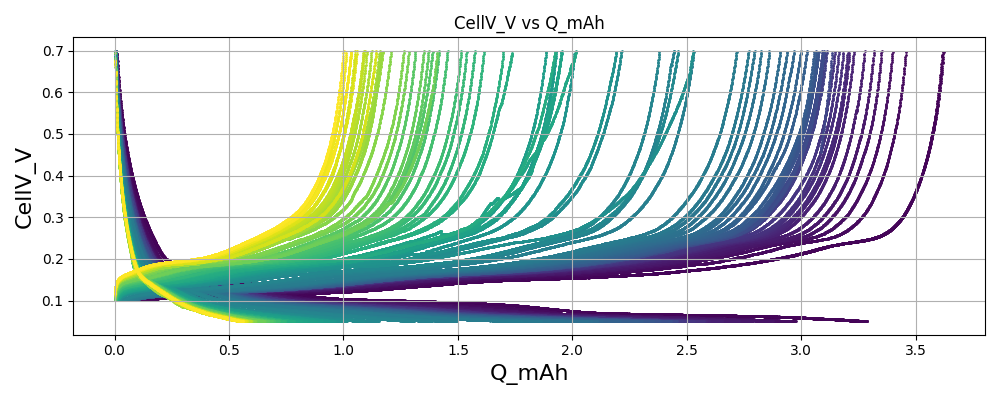

In [9]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep_truncado, vars=['Q_mAh', 'CellV_V'], nombre_grafico='plot', scatter=False)

[4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


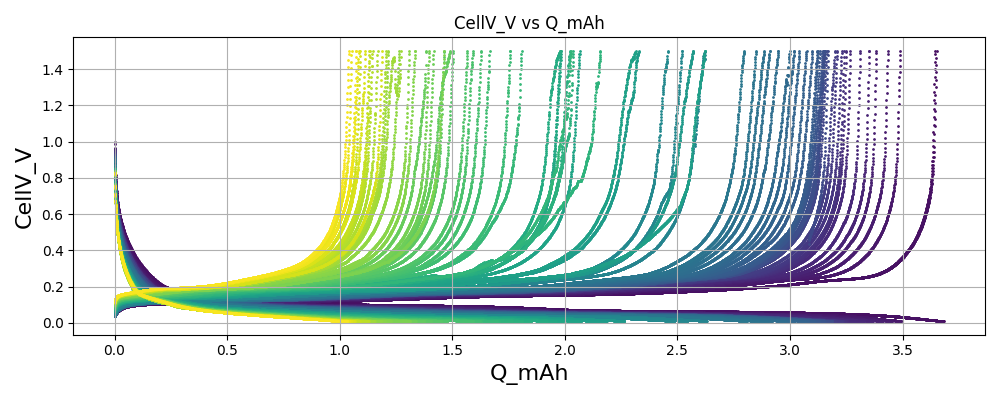

In [10]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep, semi='both', vars=['Q_mAh', 'CellV_V'], nombre_grafico='plot', scatter=False)

In [11]:
import matplotlib.pyplot as plt

def grafico_individual(ciclo, x=dict_ciclos_sep[3]['Ch']['CellV_V'], y=dict_ciclos_sep[3]['Ch']['Q_mAh'], xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    plt.scatter(x,y, s=2)
    plt.xlabel(x.name)
    plt.ylabel(y.name)
    plt.title(f'Cycle {ciclo} - {x.name} vs {y.name}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.show()

In [12]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def grafico_multiples(indices, dict_ciclos_sep, x='CellV_V', y='Q_mAh', xlim=None, ylim=None):

    plt.figure(figsize=(6,5))
    
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(indices))) # paleta completa (uno por cada ciclo real)
    color_map = {c: colors[i] for i, c in enumerate(indices)} # map: ciclo_real -> color_correcto

    for i in indices:
        color = color_map[i]
        df_ch = dict_ciclos_sep[i]['Ch']
        df_dis = dict_ciclos_sep[i]['Dis']
        
        plt.plot(df_ch[x],df_ch[y], color=color,label=f'Cycle {i}', linewidth=1)
        plt.plot(df_dis[x],df_dis[y], color=color, linewidth=1)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'Cicos {indices[0]}-{indices[-1]} - {x} vs {y}')
    plt.xlim(xlim)
    plt.ylim(ylim)
    #plt.legend()
    plt.grid()
    plt.show()

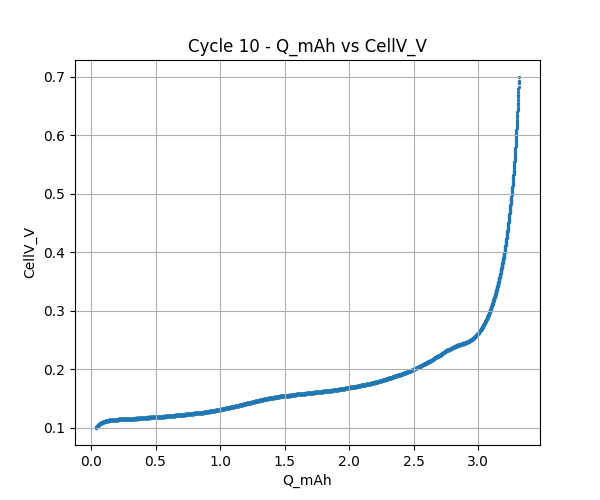

In [13]:
# Miro ciclos individualmente
ciclo = 10
grafico_individual(ciclo, x=dict_ciclos_sep_truncado[ciclo]['Ch']['Q_mAh'], y=dict_ciclos_sep_truncado[ciclo]['Ch']['CellV_V'])#, xlim=(-0.001,0.05), ylim=(-0.2,0.2))  

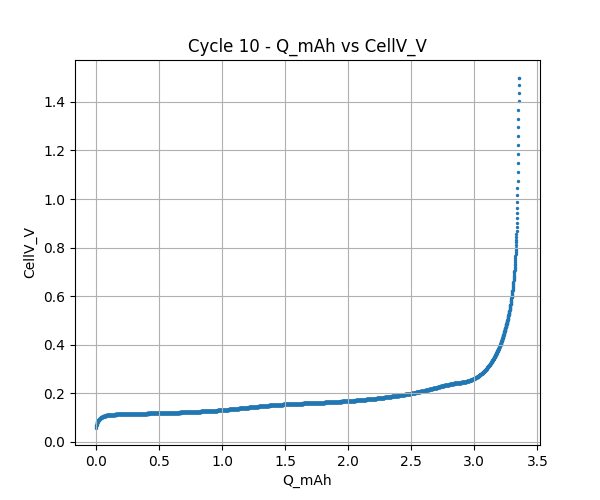

In [14]:
# Miro ciclos individualmente
ciclo = 10
grafico_individual(ciclo, x=dict_ciclos_sep[ciclo]['Ch']['Q_mAh'], y=dict_ciclos_sep[ciclo]['Ch']['CellV_V'])#, xlim=(-0.001,0.05), ylim=(-0.2,0.2))  

In [15]:
dict_ciclos_sep_filtrado = icdv.deriv.aplicar_filtro(indices, dict_ciclos_sep_truncado, Q='Q_mAh', CellV='CellV_V', wl_dis=121, wl_ch=121, polyorder=3)

Index(['Time_s', 'Time_cont_s', 'Current_mA', 'CellV_V', 'Q_mAh', 'Energy_Wh',
       'dVdt_Vs', 'dQdV_mAhV', 'Q_ch_savgol', 'CellV_V_savgol', 'dvdt_calcsv',
       'dvdq_calcsv', 'dqdv_calcsv'],
      dtype='object')
Index(['Time_s', 'Time_cont_s', 'Current_mA', 'CellV_V', 'Q_mAh', 'Energy_Wh',
       'dVdt_Vs', 'dQdV_mAhV', 'Q_dis_savgol', 'CellV_V_savgol', 'dvdt_calcsv',
       'dvdq_calcsv', 'dqdv_calcsv'],
      dtype='object')


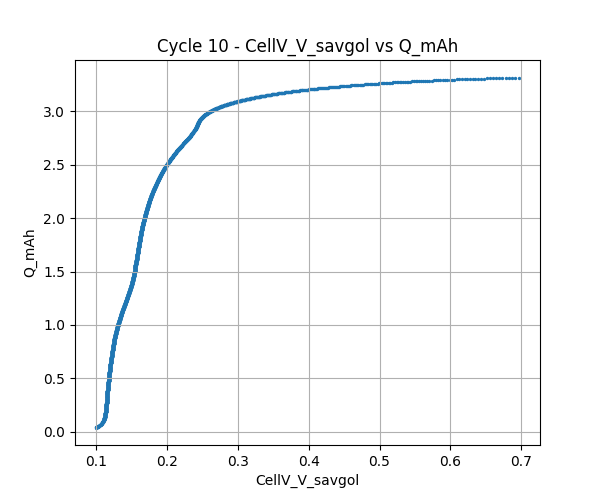

In [16]:
# Miro ciclos individualmente
ciclo = 10
grafico_individual(ciclo, x=dict_ciclos_sep_filtrado[ciclo]['Ch']['CellV_V_savgol'], y=dict_ciclos_sep_filtrado[ciclo]['Ch']['Q_mAh'])#, xlim=(0.15,0.4), ylim=(0.16,0.2))  

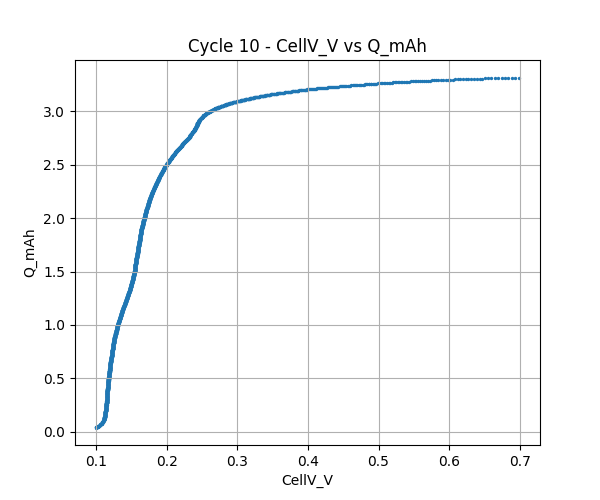

In [17]:
# Miro ciclos individualmente
ciclo = 10
grafico_individual(ciclo, x=dict_ciclos_sep_truncado[ciclo]['Ch']['CellV_V'], y=dict_ciclos_sep_truncado[ciclo]['Ch']['Q_mAh'])#, xlim=(0.15,0.4), ylim=(0.16,0.2))  

In [18]:
dict_ciclos_sep_derivada = icdv.deriv.calcular_dVdQ(indices, dict_ciclos_sep_filtrado, Q='Q_mAh', CellV='CellV_V_savgol')

In [19]:
dict_ciclos_sep_derivada[10]['Dis'].columns

Index(['Time_s', 'Time_cont_s', 'Current_mA', 'CellV_V', 'Q_mAh', 'Energy_Wh',
       'dVdt_Vs', 'dQdV_mAhV', 'Q_dis_savgol', 'CellV_V_savgol', 'dvdt_calcsv',
       'dvdq_calcsv', 'dqdv_calcsv', 'dvdq_calc', 'dqdv_calc'],
      dtype='object')

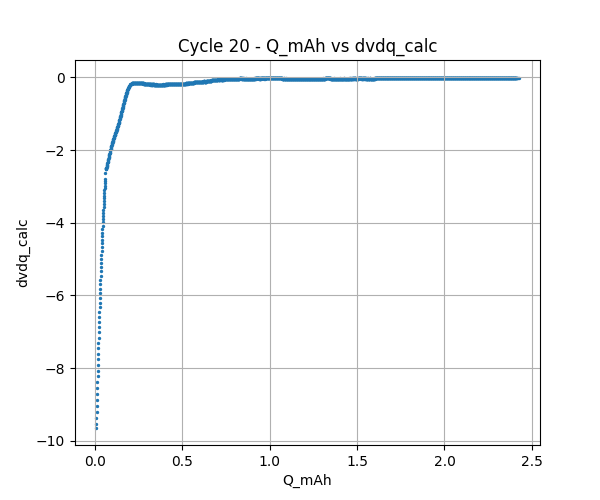

In [20]:

ciclo = 20
grafico_individual(ciclo, x=dict_ciclos_sep_derivada[ciclo]['Dis']['Q_mAh'], y=dict_ciclos_sep_derivada[ciclo]['Dis']['dvdq_calc'])#, xlim=(0.15,0.4), ylim=(0.16,0.2))

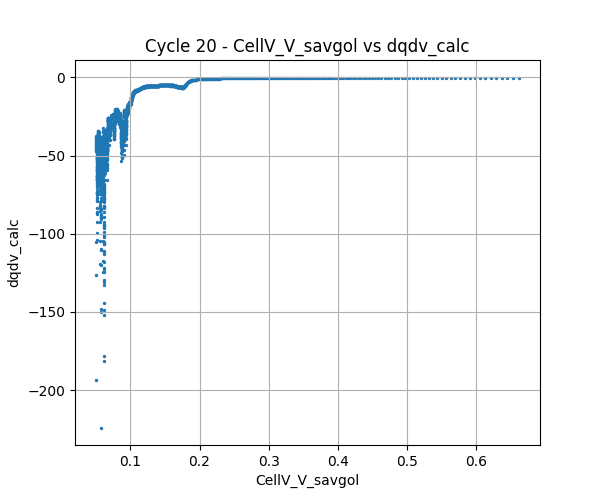

In [21]:
ciclo = 20
grafico_individual(ciclo, x=dict_ciclos_sep_derivada[ciclo]['Dis']['CellV_V_savgol'], y=dict_ciclos_sep_derivada[ciclo]['Dis']['dqdv_calc'])#, xlim=(0.15,0.4), ylim=(0.16,0.2))

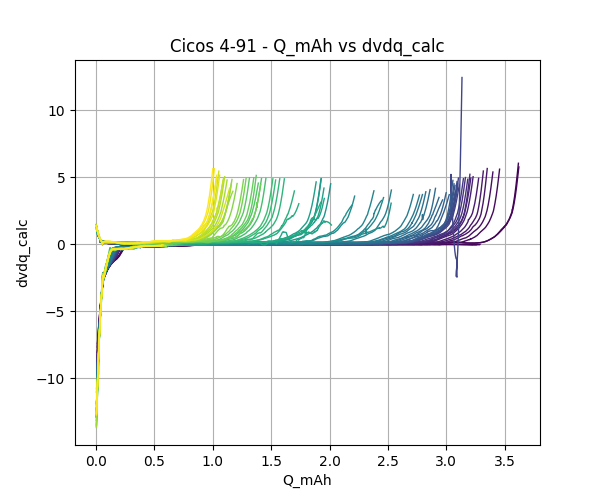

In [22]:
grafico_multiples(indices[:], dict_ciclos_sep_derivada, x='Q_mAh', y='dvdq_calc')#, xlim=(-0.5,5), ylim=(-5,10))

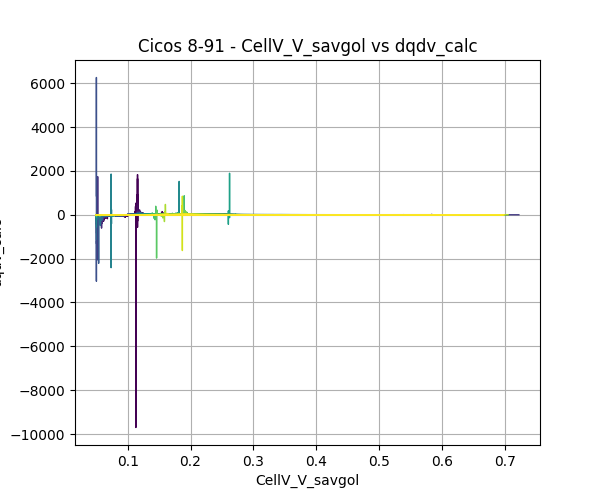

In [23]:
grafico_multiples(indices[3:], dict_ciclos_sep_derivada, x='CellV_V_savgol', y='dqdv_calc')#, xlim=(-0.1,1.4), ylim=(-200,200))

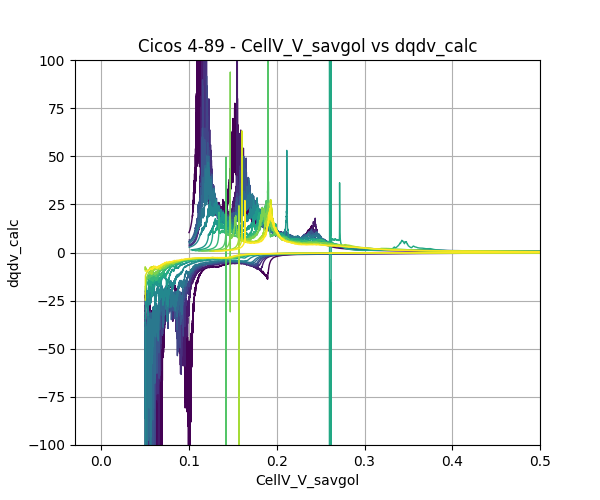

In [24]:
grafico_multiples(indices[::5], dict_ciclos_sep_derivada, x='CellV_V_savgol', y='dqdv_calc', xlim=(-0.03,0.5), ylim=(-100,100))

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 42, 43, 44, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91]


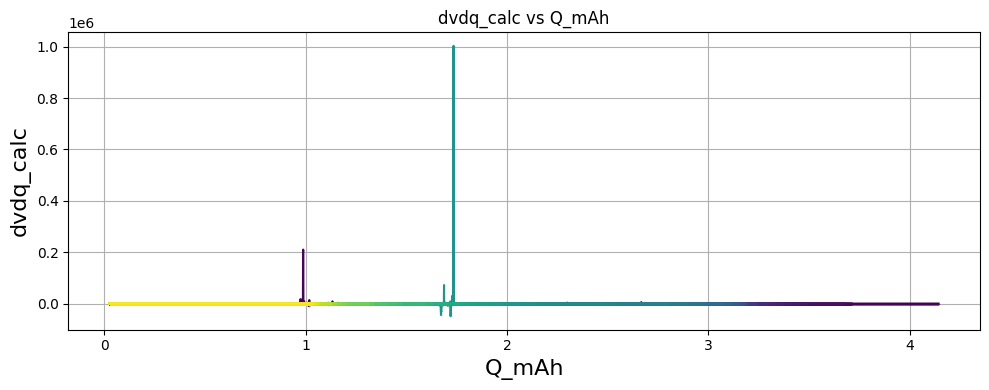

In [112]:
icdv.plotting.plot_n_cycles_QvsV_ARBIN(indices[:], dict_ciclos_sep_derivada, vars=['Q_mAh', 'dvdq_calc'], graficar='Dis', scatter=False)

# Vemos calidad de la señal para el ciclo 10

In [77]:
# veo "resolucion efectiva" de V en el dataset
V = dict_ciclos_sep[10]['Ch']['CellV'].values
dv = np.diff(np.unique(V))
np.min(dv), np.median(dv)

(np.float64(0.00030696392059317845), np.float64(0.0003069788217545111))

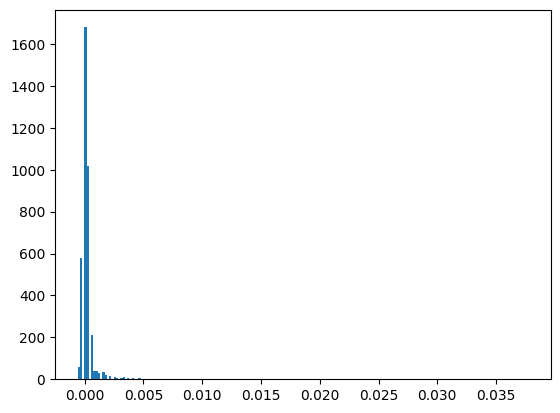

In [ ]:
# distribución de los pasos de V, si el pico en 0 es grande, es porque tengo muchos datos repetidos, y eso es malo para el cálculo de dQ/dV
plt.hist(np.diff(V), bins=200)
plt.show()

In [57]:
# veo "resolucion efectiva" de t en el dataset
t = dict_ciclos_sep[10]['Ch']['Time'].values
dt = np.diff(np.unique(t))
np.min(dt), np.median(dt)

(np.float64(0.0055602316342662945), np.float64(5.308379015884384))

(array([382., 382., 381., 382., 381., 382., 381., 382., 381., 383.]),
 array([5.56023163e-03, 1.06585350e+00, 2.12614677e+00, 3.18644004e+00,
        4.24673331e+00, 5.30702658e+00, 6.36731985e+00, 7.42761313e+00,
        8.48790640e+00, 9.54819967e+00, 1.06084929e+01]),
 <BarContainer object of 10 artists>)

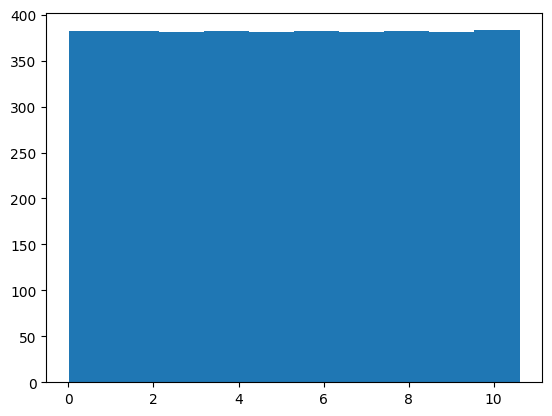

In [74]:
# distribución de los pasos dt, si el pico en 0 es grande, es porque tengo muchos datos repetidos, y eso es malo para el cálculo de dQ/dV
plt.hist(np.diff(t))#, bins=200)
#plt.show()

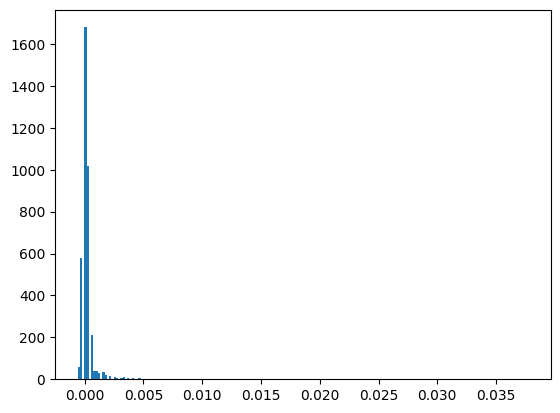

In [36]:
V = dict_ciclos_sep[10]['Ch']['CellV'].values

plt.hist(np.diff(V), bins=200)
plt.show()

In [37]:
dV = np.diff(V)

print(np.percentile(np.abs(dV), [1, 5, 10, 50]))

[0.         0.         0.         0.00030698]


In [29]:
# Quitar ciclos anómalos
indices = [i for i in indices if i not in [6,39,40,46,49,92]]

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


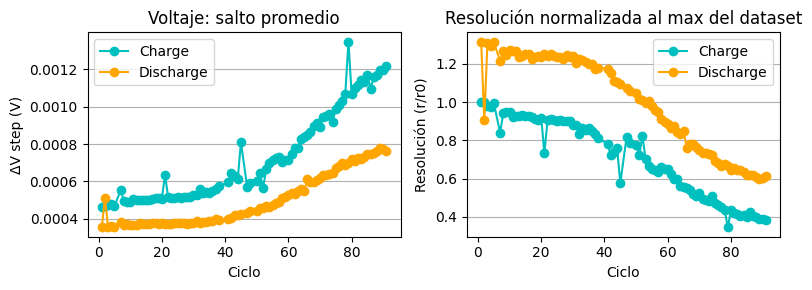

Puntos promedio por ventana de 2 mV:


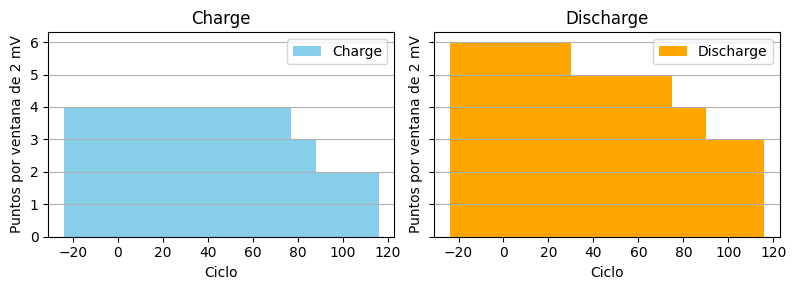

In [30]:
# Vemos resolución datos

icdv.utils_deriv.resolucion_V(indices, dict_ciclos_sep)

ValueError: If mode is 'interp', window_length must be less than or equal to the size of x.

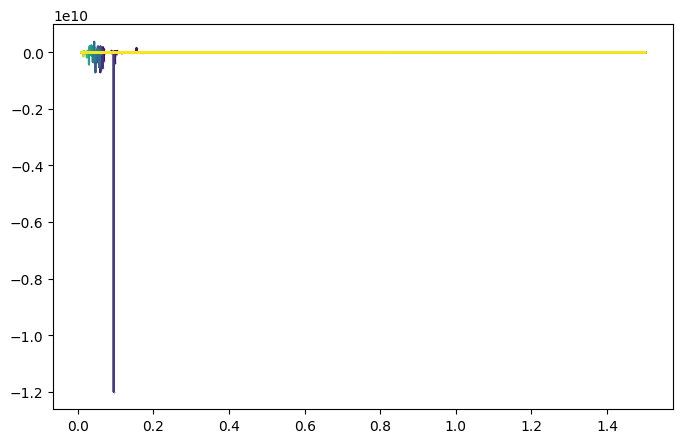

In [14]:
icdv.deriv.plot_dqdV(indices, dict_ciclos_sep)